In [1]:
!pip install -q transformers datasets accelerate evaluate scikit-learn huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [2]:
import torch
from transformers import AutoTokenizer
from datasets import load_dataset

In [3]:
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False No GPU


In [4]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/validation-00000-of-00001.parq(…): reconstructing file:   0%|          |  0.00B /  167kB            

sentiment/validation-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [6]:
print(dataset["train"][0])
print(dataset["test"][0])
print(dataset["validation"][0])

{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', 'label': 2}
{'text': "@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that.", 'label': 1}
{'text': 'Dark Souls 3 April Launch Date Confirmed With New Trailer: Embrace the darkness.', 'label': 1}


In [7]:
print(dataset["train"].features["label"])

ClassLabel(names=['negative', 'neutral', 'positive'])


In [8]:
label_feature = dataset["train"].features["label"]

In [9]:
print(label_feature.int2str(0))
print(label_feature.int2str(1))
print(label_feature.int2str(2))

negative
neutral
positive


In [10]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [11]:
print(tokenizer.special_tokens_map)

{'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


In [12]:
#let's test the tokenizer
text = "I love this!"
token_ids = tokenizer.encode(text)

In [13]:
print(tokenizer.tokenize("unbelievability"))

['un', '##bel', '##ie', '##va', '##bility']


**PyTorch Model**

In [ ]:
import torch
import torch.nn as nn

class DistilBertEmbeddings(nn.Module):

    def __init__(self, vocab_size=30522, hidden_size=768, max_position_embeddings=512, dropout_prob=0.1):
        super().__init__()

        self.word_embeddings = nn.Embedding(vocab_size, hidden_size)
        self.position_embeddings = nn.Embedding(max_position_embeddings, hidden_size)
        self.LayerNorm = nn.LayerNorm(hidden_size, eps=1e-12)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, input_ids):
        """
        input_ids: LongTensor of shape (B, seq_len)
                   e.g. (1, 128) for our "I love this!" example

        Returns: embeddings of shape (B, seq_len, hidden_size)
                 e.g. (1, 128, 768)
        """
        batch_size, seq_len = input_ids.shape
        token_embeds = self.word_embeddings(input_ids)
        position_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand(batch_size, seq_len)
        position_embeds = self.position_embeddings(position_ids)
        embeddings = token_embeds + position_embeds
        embeddings = self.LayerNorm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings

In [ ]:
class NaiveClassifier(nn.Module):
    
    def __init__(self, hidden_size=768, num_labels=3, dropout_prob=0.1):
        super().__init__()

        self.embeddings = DistilBertEmbeddings(hidden_size=hidden_size)
        self.pre_classifier = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids):
        """
        input_ids: LongTensor of shape (B, seq_len)  e.g. (1, 128)

        Returns: logits of shape (B, num_labels)  e.g. (1, 3)
        """
        embeddings = self.embeddings(input_ids)
        cls_output = embeddings[:, 0, :]
        pooled_output = self.pre_classifier(cls_output)
        pooled_output = torch.relu(pooled_output)  # ReLU activation, adds non-linearity
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return logits

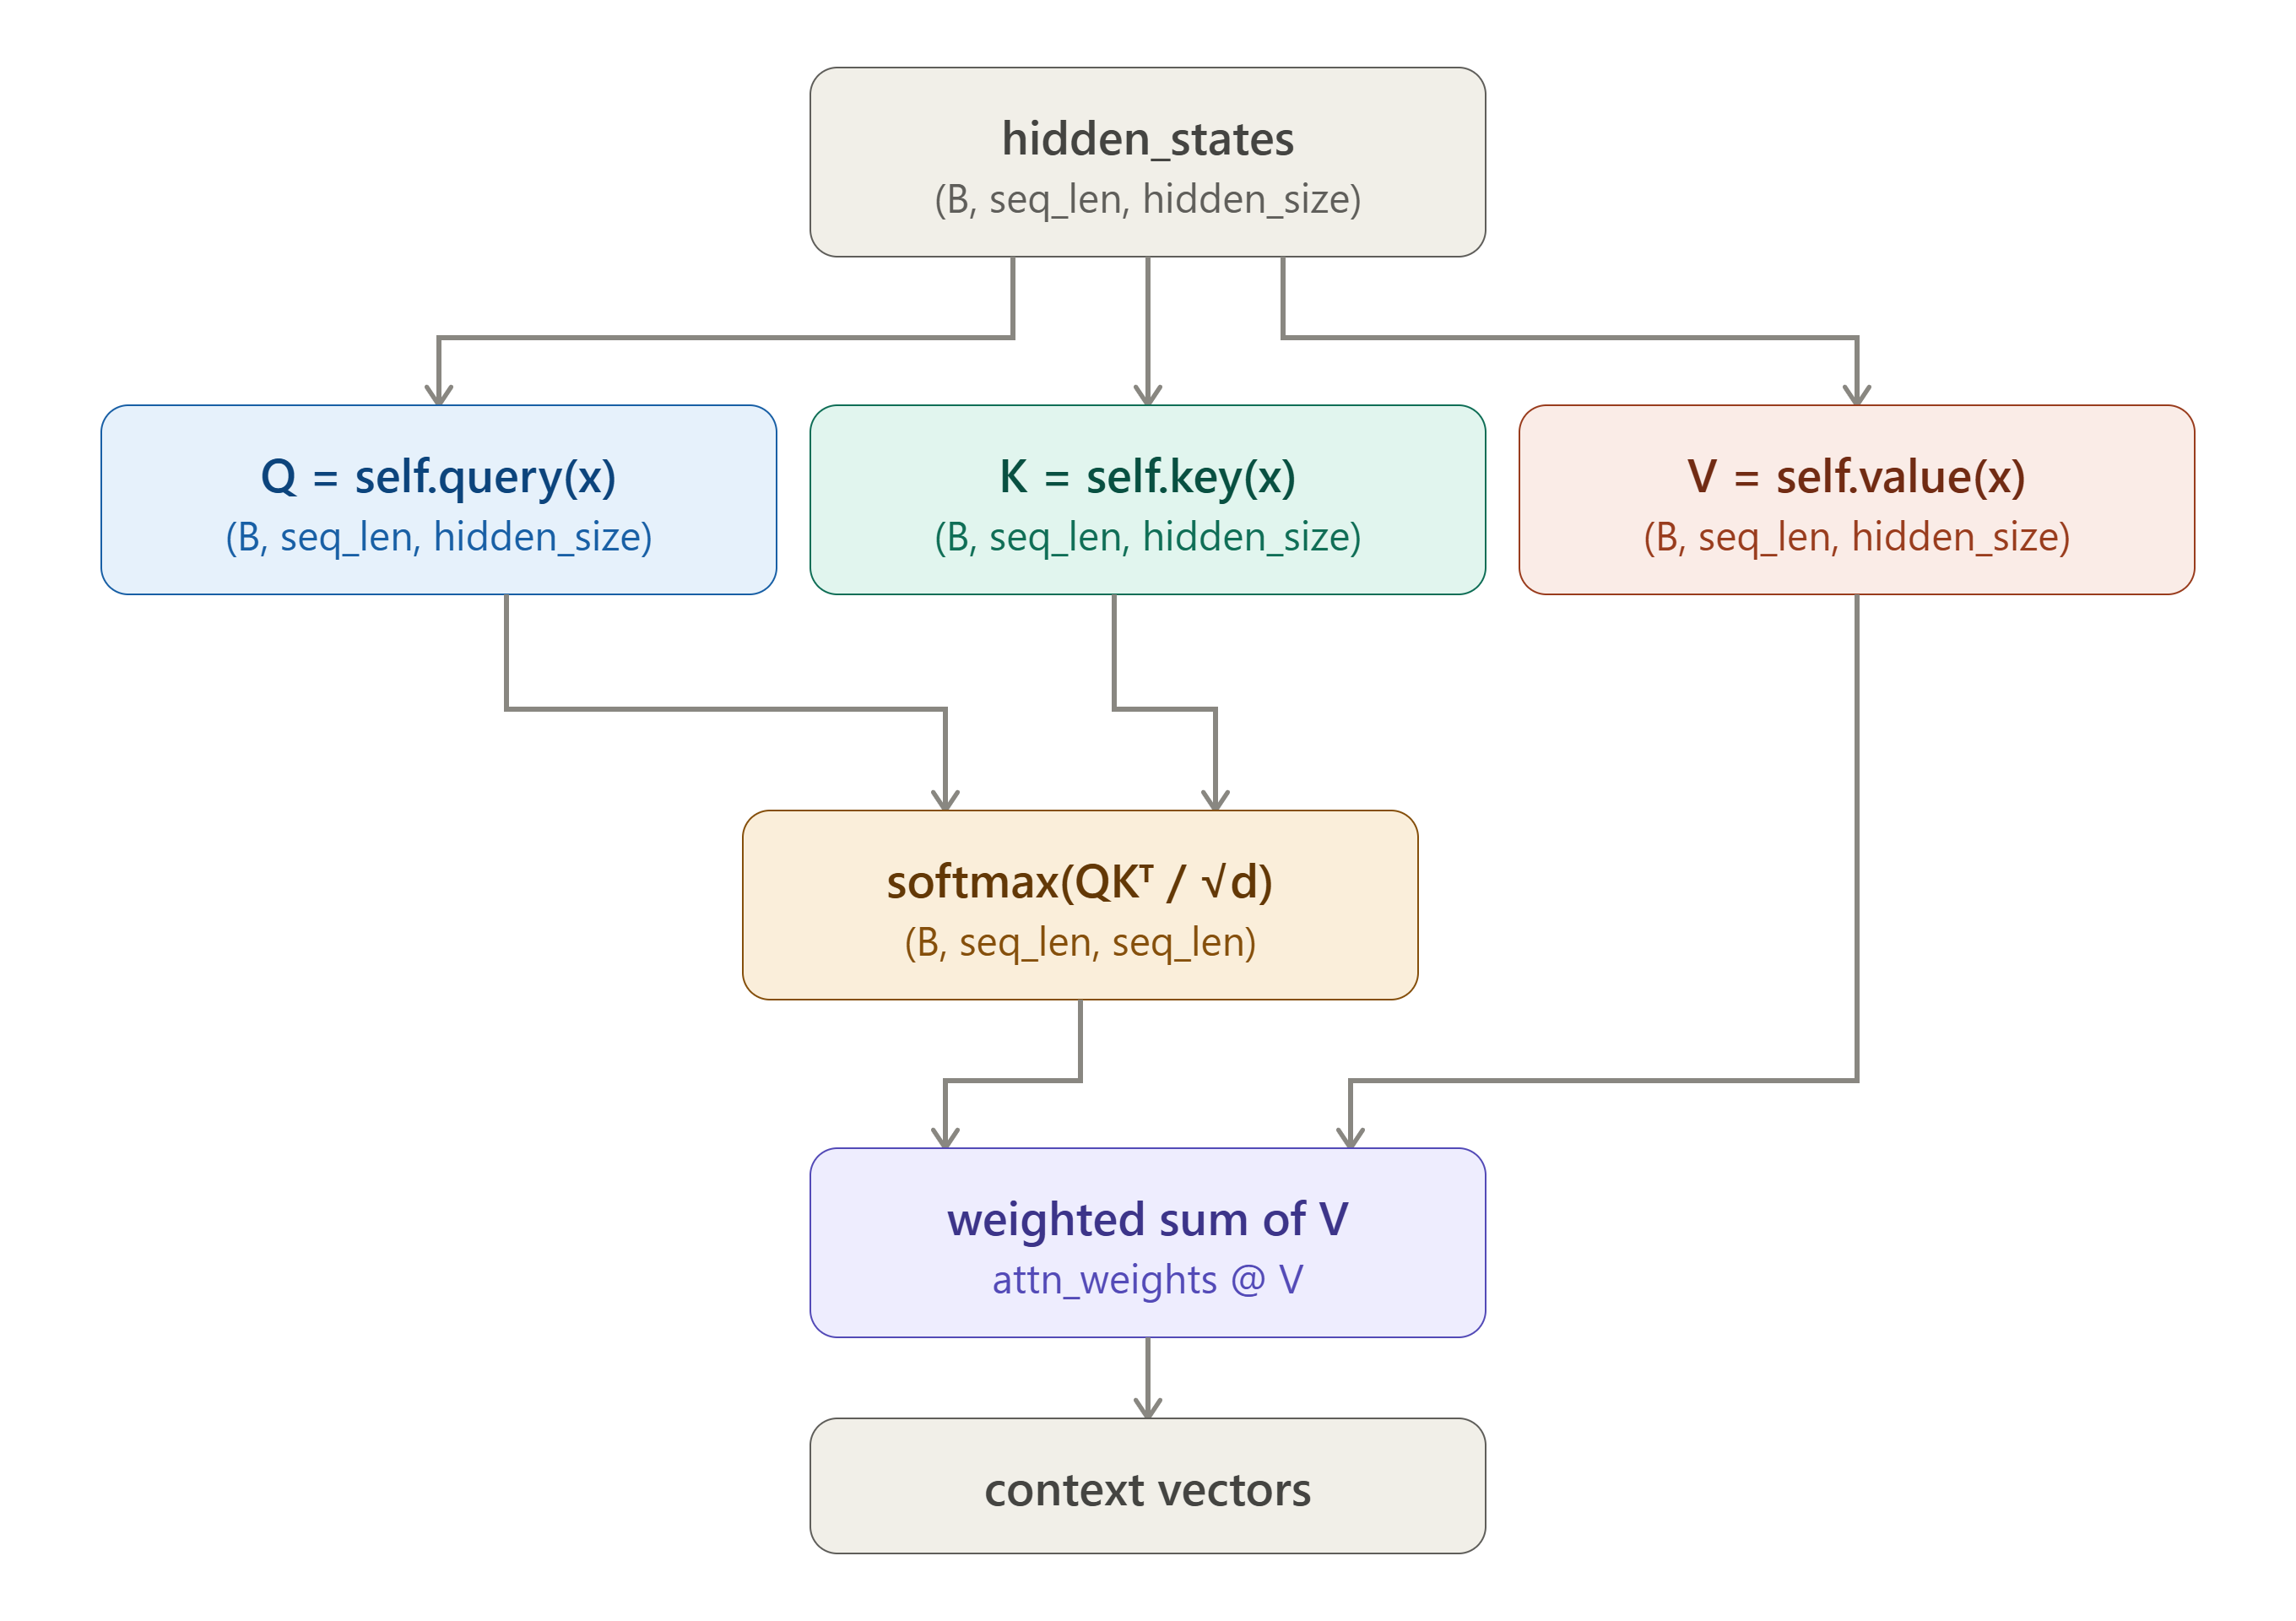

In [ ]:
import math

class SelfAttention(nn.Module):

    def __init__(self, hidden_size=768):
        super().__init__()
        self.hidden_size = hidden_size
        self.query = nn.Linear(hidden_size, hidden_size)
        self.key = nn.Linear(hidden_size, hidden_size)
        self.value = nn.Linear(hidden_size, hidden_size)

    def forward(self, hidden_states, attention_mask):
        """
        hidden_states:  (B, seq_len, hidden_size)  e.g. (1, 128, 768)
                         - this is the output of the embedding layer
        attention_mask: (B, seq_len)  e.g. (1, 128)
                         - 1 for real tokens, 0 for padding

        Returns: context vectors of shape (B, seq_len, hidden_size)
                 - same shape as input, but now every position's vector
                   has absorbed information from other relevant positions
        """

        Q = self.query(hidden_states)
        K = self.key(hidden_states)
        V = self.value(hidden_states)

        scores = torch.matmul(Q, K.transpose(-2, -1))
        scores = scores / math.sqrt(self.hidden_size)
        extended_mask = attention_mask[:, None, :]  # (B, seq_len) -> (B, 1, seq_len)
        scores = scores.masked_fill(extended_mask == 0, float('-inf'))
        attention_weights = torch.softmax(scores, dim=-1)
        context = torch.matmul(attention_weights, V)

        return context, attention_weights

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    
    def __init__(self, hidden_size=768, num_heads=12):
        super().__init__()

        assert hidden_size % num_heads == 0, "hidden_size must be divisible by num_heads"

        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads  # 768 // 12 = 64

        self.query = nn.Linear(hidden_size, hidden_size)
        self.key = nn.Linear(hidden_size, hidden_size)
        self.value = nn.Linear(hidden_size, hidden_size)  

        self.output_proj = nn.Linear(hidden_size, hidden_size)

    def split_heads(self, x, batch_size):
        """
        Reshape (B, seq_len, hidden_size) -> (B, num_heads, seq_len, head_dim)

        This is the core trick that turns ONE big 768-dim vector per token
        into 12 separate 64-dim "views" of it, one per head.
        """
        seq_len = x.shape[1]
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)

        return x

    def forward(self, hidden_states, attention_mask):
        """
        hidden_states:  (B, seq_len, hidden_size)  e.g. (1, 128, 768)
        attention_mask: (B, seq_len)  e.g. (1, 128)

        Returns: (B, seq_len, hidden_size)  e.g. (1, 128, 768)
                 - same shape as input, same as Phase 3's output shape,
                   but now computed using 12 parallel attention heads
                   instead of just 1.
        """
        batch_size = hidden_states.shape[0]

        Q = self.query(hidden_states)
        K = self.key(hidden_states)
        V = self.value(hidden_states)

        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        scores = torch.matmul(Q, K.transpose(-2, -1))

        scores = scores / math.sqrt(self.head_dim)

        extended_mask = attention_mask[:, None, None, :]
        scores = scores.masked_fill(extended_mask == 0, float('-inf'))
        attention_weights = torch.softmax(scores, dim=-1)
        context = torch.matmul(attention_weights, V)
        context = context.transpose(1, 2).contiguous()
        context = context.view(batch_size, -1, self.hidden_size)

        output = self.output_proj(context)

        return output, attention_weights

In [ ]:
class FeedForward(nn.Module):

    def __init__(self, hidden_size=768, intermediate_size=3072, dropout_prob=0.1):
        super().__init__()

        # Expand: 768 -> 3072
        self.linear1 = nn.Linear(hidden_size, intermediate_size)

        self.activation = nn.GELU()

        # Compress back: 3072 -> 768
        self.linear2 = nn.Linear(intermediate_size, hidden_size)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        
        # (B, seq_len, 768) -> (B, seq_len, 3072)
        x = self.linear1(x)
        x = self.activation(x)
        x = self.dropout(x)

        # (B, seq_len, 3072) -> (B, seq_len, 768)
        x = self.linear2(x)

        return x


In [ ]:

class TransformerBlock(nn.Module):
    """
    PHASE 5b: One complete Transformer block/layer.

    Combines:
      1. Multi-head self-attention (Phase 4)
      2. Residual connection + LayerNorm ("Add & Norm")
      3. Feed-forward network (Phase 5a)
      4. Another residual connection + LayerNorm ("Add & Norm")

    """

    def __init__(self, hidden_size=768, num_heads=12, intermediate_size=3072, dropout_prob=0.1):
        super().__init__()

        self.attention = MultiHeadSelfAttention(hidden_size=hidden_size, num_heads=num_heads)
        self.attention_layer_norm = nn.LayerNorm(hidden_size, eps=1e-12)
        self.attention_dropout = nn.Dropout(dropout_prob)

        self.ffn = FeedForward(hidden_size=hidden_size, intermediate_size=intermediate_size, dropout_prob=dropout_prob)
        self.ffn_layer_norm = nn.LayerNorm(hidden_size, eps=1e-12)
        self.ffn_dropout = nn.Dropout(dropout_prob)

    def forward(self, hidden_states, attention_mask):
        
        # --- Sub-layer 1: Multi-head attention ---
        attention_output = self.attention(hidden_states, attention_mask)
        # Shape: (B, seq_len, hidden_size), unchanged
        
        attention_output = self.attention_dropout(attention_output)
        hidden_states = self.attention_layer_norm(hidden_states + attention_output)

        ffn_output = self.ffn(hidden_states)
        # Shape: (B, seq_len, hidden_size), unchanged (expands to 3072 internally, then back to 768)

        ffn_output = self.ffn_dropout(ffn_output)

        # --- Add & Norm --
        hidden_states = self.ffn_layer_norm(hidden_states + ffn_output)

        return hidden_states

In [ ]:
class TransformerEncoder(nn.Module):
   

    def __init__(self, num_layers=6, hidden_size=768, num_heads=12, intermediate_size=3072, dropout_prob=0.1):
        super().__init__()

        self.layers = nn.ModuleList([
            TransformerBlock(
                hidden_size=hidden_size,
                num_heads=num_heads,
                intermediate_size=intermediate_size,
                dropout_prob=dropout_prob
            )
            for _ in range(num_layers)
        ])

    def forward(self, hidden_states, attention_mask):

        for layer in self.layers:
            hidden_states = layer(hidden_states, attention_mask)

        return hidden_states

In [ ]:
class DistilBertForSentimentClassification(nn.Module):

    def __init__(self, vocab_size=30522, hidden_size=768, num_layers=6,
                 num_heads=12, intermediate_size=3072, num_labels=3,
                 max_position_embeddings=512, dropout_prob=0.1):
        super().__init__()

        # --- Embedding layer (Phase 1) ---
        self.embeddings = DistilBertEmbeddings(
            vocab_size=vocab_size,
            hidden_size=hidden_size,
            max_position_embeddings=max_position_embeddings,
            dropout_prob=dropout_prob
        )

        # --- 6-layer Transformer encoder (Phase 6) ---
        self.encoder = TransformerEncoder(
            num_layers=num_layers,
            hidden_size=hidden_size,
            num_heads=num_heads,
            intermediate_size=intermediate_size,
            dropout_prob=dropout_prob
        )

        # --- Classification head ---
        self.pre_classifier = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        
        # Step 1: Embeddings 
        # (B, seq_len) -> (B, seq_len, hidden_size)  e.g. (1, 128) -> (1, 128, 768)
        embeddings = self.embeddings(input_ids)

        encoder_output = self.encoder(embeddings, attention_mask)

        cls_output = encoder_output[:, 0, :]

        pooled_output = self.pre_classifier(cls_output)
        pooled_output = torch.relu(pooled_output)

        # --- Step 5: Dropout ---
        pooled_output = self.dropout(pooled_output)

        # (B, hidden_size) -> (B, num_labels)  e.g. (1, 768) -> (1, 3)
        logits = self.classifier(pooled_output)

        return logits

**Training Loop**

**1. let's create tokenized dataset**

In [ ]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_dataset = dataset.map(tokenize_function, batched=True)

In [ ]:
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset = tokenized_dataset.remove_columns(["text", "token_type_ids"])
tokenized_dataset.set_format("torch")
print(tokenized_dataset)

**2. Datacollator, we will be using for batches management during training**

In [ ]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

**removing unnecessary columns and renaming columns on the same Distilbert format**

In [ ]:
from torch.utils.data import DataLoader

# DataLoader handles: shuffling, batching, and calling data_collator
# to combine individual examples into batched tensors - same collator

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    batch_size=16,
    shuffle=True,           # reshuffle data every epoch - important for training,
                             # prevents the model from learning any accidental
                             # ordering patterns in the dataset
    collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_dataset["validation"],
    batch_size=16,
    shuffle=False,           # no need to shuffle for evaluation
    collate_fn=data_collator
)

# Quick check: pull one batch and inspect it
batch = next(iter(train_dataloader))
print(batch.keys())              
print(batch["input_ids"].shape)  
print(batch["labels"].shape)     

In [ ]:
import torch.nn as nn
from torch.optim import AdamW
model = DistilBertForSentimentClassification()

loss_fn = nn.CrossEntropyLoss()

optimizer = AdamW(model.parameters(), lr=2e-5)

print(loss_fn)
print(optimizer)

**Let's move our model to GPU**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Model is on:", next(model.parameters()).device)

In [ ]:
first_param = next(model.parameters())
print(first_param.shape)   # e.g. torch.Size([30522, 768]) - the embedding table
print(first_param.device) 

In [ ]:
model.train()  # sets the model to TRAINING mode (activates Dropout properly)

batch = next(iter(train_dataloader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

# Forward pass 
logits = model(input_ids, attention_mask)
print("logits shape:", logits.shape)  # (16, 3)

# Compute loss 
loss = loss_fn(logits, labels)
print("loss:", loss.item())

# Backward pass
loss.backward()

# Optimizer step
optimizer.step()

# Zero gradients
optimizer.zero_grad()

print("One training step completed successfully")

In [ ]:
import time

num_epochs = 3

for epoch in range(num_epochs):
    model.train() 
    total_train_loss = 0
    start_time = time.time()

    for step, batch in enumerate(train_dataloader):
        
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)

        # Backward pass + optimizer step
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_train_loss += loss.item()

        # Print progress every 200 steps, so we can see training happening
        if step % 200 == 0:
            print(f"Epoch {epoch+1} | Step {step}/{len(train_dataloader)} | Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_dataloader)
    epoch_time = time.time() - start_time
    print(f"\nEpoch {epoch+1} finished | Avg Train Loss: {avg_train_loss:.4f} | Time: {epoch_time:.1f}s\n")

    model.eval()  
                   
    total_eval_loss = 0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad(): 
        for batch in eval_dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)
            total_eval_loss += loss.item()

            predictions = torch.argmax(logits, dim=-1)  # pick highest-scoring class
            correct_predictions += (predictions == labels).sum().item()
            total_predictions += labels.size(0)

    avg_eval_loss = total_eval_loss / len(eval_dataloader)
    accuracy = correct_predictions / total_predictions
    print(f"Epoch {epoch+1} | Validation Loss: {avg_eval_loss:.4f} | Validation Accuracy: {accuracy:.4f}\n")
    print("=" * 60)

**Testing model with multiple sentences**

In [ ]:
model.eval()  # deactivate Dropout for clean, consistent predictions

id2label = {0: "negative", 1: "neutral", 2: "positive"}

def predict_sentiment(text, model, tokenizer, device):
    inputs = tokenizer(text, padding="max_length", max_length=128, truncation=True, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():  # no need for gradients during inference
        logits = model(input_ids, attention_mask)

    probs = torch.softmax(logits, dim=-1)   # convert logits to probabilities
    predicted_class = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][predicted_class].item()

    return id2label[predicted_class], confidence


# Try a few example sentences
examples = [
    "I absolutely love this new phone, it is amazing!",
    "This is the worst service I've ever experienced.",
    "The meeting is scheduled for 3pm tomorrow.",
    "I'm not sure how I feel about this, it's kind of mixed.",
    "Wow, absolutely incredible experience, would recommend to everyone!",
]

for text in examples:
    label, confidence = predict_sentiment(text, model, tokenizer, device)
    print(f"{text}\n → {label} (confidence: {confidence:.3f})\n")

**Saving checkpoints of model**

In [ ]:
import torch

checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": epoch,                          # last completed epoch 
    "avg_train_loss": avg_train_loss,        # last recorded training loss
    "avg_eval_loss": avg_eval_loss,          # last recorded validation loss
    "accuracy": accuracy,                     # last recorded validation accuracy
}

# Save to Google Drive
from google.colab import drive
drive.mount('/content/drive')

torch.save(checkpoint, "/content/drive/MyDrive/distilbert-scratch-checkpoint.pt")
print("Checkpoint saved successfully.")

**Re-loading model**

In [ ]:
# Recreate the model architecture first
model = DistilBertForSentimentClassification(
    vocab_size=30522, hidden_size=768, num_layers=6,
    num_heads=12, intermediate_size=3072, num_labels=3
)
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

# Load the checkpoint
checkpoint = torch.load("/content/drive/MyDrive/distilbert-scratch-checkpoint.pt")

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"] + 1  # resume from the next epoch
print(f"Resuming from epoch {start_epoch}")
print(f"Last recorded accuracy: {checkpoint['accuracy']:.4f}")

## **Multi Query Attention**

In [ ]:
model_config = {
    "vocab_size": 30522,
    "dim": 768,
    "max_seq_length":512,
    "drop_out_emb" : 0.1,
    "num_labels": 3,
    "classifier_dropout": 0.2,
    "num_heads":12,
    "dropout_mha":0.1,
    "hidden_size":3072,
    "dropout_ffn": 0.1

}

In [ ]:
class MultiHeadAttentionMQA(nn.Module):
  def __init__(self,num_heads=model_config["num_heads"], dim=model_config["dim"], 
              dropout_p = model_config["dropout_mha"], head_dim_kv=64):
    super().__init__()

    self.num_heads = num_heads
    assert dim % num_heads == 0
    self.head_dim = dim // num_heads
    
    self.q_lin = nn.Linear(dim, dim)
    self.k_lin = nn.Linear(dim, head_dim_kv)
    self.v_lin = nn.Linear(dim, head_dim_kv)
    self.out_lin = nn.Linear(dim, dim)
    self.dropout = nn.Dropout(p=dropout_p)

  def generate_heads(self, x, batch_size):

    return x.view(batch_size, x.shape[1], self.num_heads, self.head_dim).transpose(1,2)

  def forward(self, input_embeddings, attention_mask):
    batch_size = input_embeddings.shape[0]
    Q = self.q_lin(input_embeddings)
    K = self.k_lin(input_embeddings)
    V = self.v_lin(input_embeddings)

    Q = self.generate_heads(Q, batch_size)
    # K = self.generate_heads(K, batch_size)
    # V = self.generate_heads(V, batch_size)
    K = K[:,None,:,:]
    V = V[:,None,:,:]
    scores = torch.matmul(Q, K.transpose(-2,-1))
    scores = scores / math.sqrt(self.head_dim)
    extended_attention_mask = attention_mask[:,None,None,:]
    masked_scores = scores.masked_fill(extended_attention_mask == 0, float("-inf"))
    weights = torch.softmax(masked_scores, dim=-1)
    context = torch.matmul(weights, V)

    context = context.transpose(1,2).contiguous().view(batch_size, -1 ,self.num_heads * self.head_dim)
    output = self.out_lin(context)
    output = self.dropout(output)

    return output


## **Grouped Query Attention**

In [ ]:
class MultiHeadAttentionGQA(nn.Module):
  def __init__(self, num_heads=model_config["num_heads"], dim=model_config["dim"],
             dropout_p=model_config["dropout_mha"], num_kv_groups=4):
    super().__init__()

    self.num_heads = num_heads
    self.num_kv_groups = num_kv_groups
    assert dim % num_heads == 0
    assert num_heads % num_kv_groups == 0   # heads must split evenly into groups

    self.head_dim = dim // num_heads
    self.q_lin = nn.Linear(dim, dim)
    self.k_lin = nn.Linear(dim, num_kv_groups * self.head_dim)
    self.v_lin = nn.Linear(dim, num_kv_groups * self.head_dim)
    self.out_lin = nn.Linear(dim, dim)
    self.dropout = nn.Dropout(p=dropout_p)
  
  def generate_kv_heads(self, x, batch_size):
    return x.view(batch_size, x.shape[1], self.num_kv_groups, self.head_dim).transpose(1, 2)

  def generate_heads(self, x, batch_size):

    return x.view(batch_size, x.shape[1], self.num_heads, self.head_dim).transpose(1,2)

  def forward(self, input_embeddings, attention_mask):
    batch_size = input_embeddings.shape[0]
    Q = self.q_lin(input_embeddings)
    K = self.k_lin(input_embeddings)
    V = self.v_lin(input_embeddings)

    Q = self.generate_heads(Q, batch_size)          # (B, num_heads, seq, head_dim)
    K = self.generate_kv_heads(K, batch_size)        # (B, num_kv_groups, seq, head_dim)
    V = self.generate_kv_heads(V, batch_size)         # (B, num_kv_groups, seq, head_dim)

    repeat_factor = self.num_heads // self.num_kv_groups
    K = K.repeat_interleave(repeat_factor, dim=1)     # (B, (cloned)num_heads, seq, head_dim)
    V = V.repeat_interleave(repeat_factor, dim=1)

    # return K
    scores = torch.matmul(Q, K.transpose(-2, -1))
    scores = scores / math.sqrt(self.head_dim)
    extended_attention_mask = attention_mask[:, None, None, :]
    masked_scores = scores.masked_fill(extended_attention_mask == 0, float("-inf"))
    weights = torch.softmax(masked_scores, dim=-1)
    context = torch.matmul(weights, V)

    context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.head_dim)
    output = self.out_lin(context)
    output = self.dropout(output)

    return output


## **Flash Attention**

In [ ]:
import torch
import torch.nn.functional as F
import torch.nn as nn

class MultiHeadSelfAttentionFA(nn.Module):
    
    def __init__(self, hidden_size=768, num_heads=12):
        super().__init__()

        assert hidden_size % num_heads == 0, "hidden_size must be divisible by num_heads"

        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads  # 768 // 12 = 64

        self.query = nn.Linear(hidden_size, hidden_size)
        self.key = nn.Linear(hidden_size, hidden_size)
        self.value = nn.Linear(hidden_size, hidden_size)  

        self.output_proj = nn.Linear(hidden_size, hidden_size)

    def split_heads(self, x, batch_size):
        
        seq_len = x.shape[1]
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)

        return x

    def forward(self, hidden_states, attention_mask):
        
        batch_size = hidden_states.shape[0]

        Q = self.query(hidden_states)
        K = self.key(hidden_states)
        V = self.value(hidden_states)

        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        extended_mask = attention_mask[:, None, None, :].bool()
        # scores = scores.masked_fill(extended_mask == 0, float('-inf'))
        context = F.scaled_dot_product_attention(Q, K, V, attn_mask=extended_mask)
        context = context.transpose(1, 2).contiguous()
        context = context.view(batch_size, -1, self.hidden_size)

        output = self.output_proj(context)

        return output

# **Pre-LN**

in Pre-LN the residual (input_embeddings) skips the LayerNorm entirely on its path to the +, while in Post-LN the sum itself gets wrapped in LayerNorm, forcing every gradient through the 1/std (happens in Normalization) term.

In [ ]:

class TransformerBlock(nn.Module):


    def __init__(self, hidden_size=768, num_heads=12, intermediate_size=3072, dropout_prob=0.1):
        super().__init__()

        self.attention = MultiHeadSelfAttention(hidden_size=hidden_size, num_heads=num_heads)
        self.attention_layer_norm = nn.LayerNorm(hidden_size, eps=1e-12)
        self.attention_dropout = nn.Dropout(dropout_prob)

        self.ffn = FeedForward(hidden_size=hidden_size, intermediate_size=intermediate_size, dropout_prob=dropout_prob)
        self.ffn_layer_norm = nn.LayerNorm(hidden_size, eps=1e-12)
        self.ffn_dropout = nn.Dropout(dropout_prob)

    def forward(self, hidden_states, attention_mask):

        attention_output = self.attention(self.attention_layer_norm(hidden_states), attention_mask)

        attention_output = self.attention_dropout(attention_output)

        hidden_states = hidden_states + attention_output
        ffn_output = self.ffn(self.ffn_layer_norm(hidden_states))

        ffn_output = self.ffn_dropout(ffn_output)
        hidden_states = hidden_states + ffn_output

        return hidden_states